## Deep Learning, DL Models, and Applications

```python
# Task 8: Semantic Segmentation Pipeline on Pixel-wise Grids using
# custom Dice Loss
# ● Objective: Construct high-precision spatial localization engines for medical imaging and
# autonomous navigation datasets, utilizing advanced boundary overlap losses.
# ● Required Tech Stack: PyTorch, TorchVision, Albumentations, Matplotlib.
# ● Task Description: Build a deep U-Net architecture for segmenting complex image masks.
# Students must implement a custom composite loss function combining Soft Dice Loss and
# Binary Cross-Entropy, write dataset pipelines parsing large spatial target masks, and plot
# pixel-wise precision-recall boundary curves.
```

In [200]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import precision_recall_curve

In [201]:


# 1. CUSTOM COMPOSITE LOSS (Soft Dice + BCE)
class SoftDiceBCELoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        probs = torch.sigmoid(logits)

        # Flatten spatial dimensions for Dice Calculation
        p_flat = probs.view(probs.size(0), -1)
        t_flat = targets.view(targets.size(0), -1)

        intersection = (p_flat * t_flat).sum(dim=1)
        dice = (2.0 * intersection + self.smooth) / (p_flat.sum(1) + t_flat.sum(1) + self.smooth)
        dice_loss = 1.0 - dice.mean()

        return 0.5 * bce_loss + 0.5 * dice_loss


In [202]:

# 2. SIMPLE U-NET ARCHITECTURE
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DoubleConv(3, 64)
        self.pool = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(64, 128)

        self.bottleneck = DoubleConv(128, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))

        b = self.bottleneck(self.pool(e2))

        d2 = self.dec2(torch.cat([self.up2(b), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.final(d1)


In [203]:

# 3. ALBUMENTATIONS DATASET
class SimpleSegmentationDataset(Dataset):
    def __init__(self, num_samples=50):
        self.num_samples = num_samples
        self.transform = A.Compose([
            A.Resize(128, 128),
            A.HorizontalFlip(p=0.5),
            A.Normalize(),
            ToTensorV2()
        ])

    def __len__(self): return self.num_samples

    def __getitem__(self, idx):
        # Synthetic sample (RGB image & binary spatial mask)
        image = np.random.randint(0, 256, (128, 128, 3), dtype=np.uint8)
        mask = np.zeros((128, 128), dtype=np.float32)
        mask[30:90, 30:90] = 1.0  # Simple spatial target box

        aug = self.transform(image=image, mask=mask)
        return aug['image'], aug['mask'].unsqueeze(0)

In [209]:


# 4. TRAINING & EVALUATION PIPELINE
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    loader = DataLoader(SimpleSegmentationDataset(), batch_size=4, shuffle=True)
    model = UNet().to(device)
    criterion = SoftDiceBCELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # Short Training Loop
    model.train()
    print("Training...")
    for epoch in range(3):
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), masks)
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1}/3 - Loss: {loss.item():.4f}")

    # Evaluate & Plot Precision-Recall Curve
    model.eval()
    all_masks, all_preds = [], []
    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(device)
            probs = torch.sigmoid(model(imgs))
            all_masks.append(masks.cpu().numpy().ravel())
            all_preds.append(probs.cpu().numpy().ravel())

    y_true = np.concatenate(all_masks)
    y_scores = np.concatenate(all_preds)

    precision, recall, _ = precision_recall_curve(y_true, y_scores)

    # Plot PR Curve
    plt.plot(recall, precision, color='blue', label='Pixel PR Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Pixel-Wise Precision-Recall Boundary Curve')
    plt.grid(True)
    plt.show()

Training...
Epoch 1/3 - Loss: 0.5289
Epoch 2/3 - Loss: 0.4839
Epoch 3/3 - Loss: 0.4640


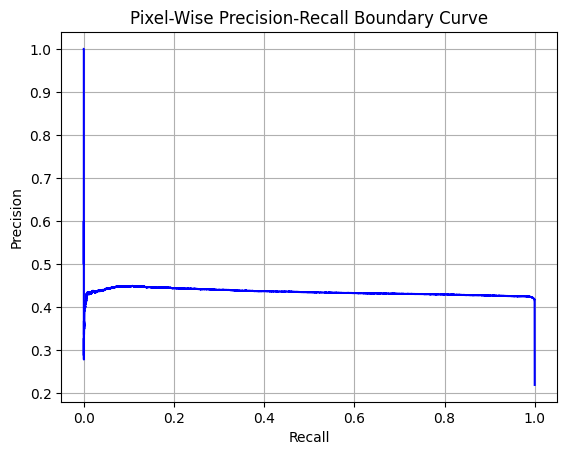

In [208]:
if __name__ == "__main__":
    main()